# Student Info
## Name: Jia Changyu
## English Name: Iris
## ID: C00292876

# 1. Introduction

This experiment aims to systematically compare the performance of three deep learning models—simple recurrent neural networks (RNNs), long short-term memory networks (LSTMs), and a Transformer model based on a self-attention mechanism—on a text sentiment classification task. The experiment uses the IMDB movie review dataset on Kaggle (containing 50,000 reviews with sentiment tags). A unified data preprocessing pipeline ensures consistency and fairness of the model inputs. This experiment aims to explore the ability of different sequence modeling techniques to capture the semantics of natural language and to provide reliable experimental evidence for model selection in practical natural language processing tasks.

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Embedding, SimpleRNN, LSTM, Dense, Dropout, SpatialDropout1D,
    Input, MultiHeadAttention, LayerNormalization, GlobalAveragePooling1D, Flatten
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2

In [101]:
dataset_path = "../data/IMDB Dataset.csv"
imbd = pd.read_csv(dataset_path)


# 2. Initial Exploration

In [102]:
print(f"Shape of the dataset: {imbd.shape}")
print(f"Dataset Information:")
print(f"  Total number of comments: {len(imbd):,}")
print(f"  Column names: {imbd.columns.tolist()}")

Shape of the dataset: (50000, 2)
Dataset Information:
  Total number of comments: 50,000
  Column names: ['review', 'sentiment']


In [103]:
print("\nDistribution of Emotional Labels:")
sentiment_counts = imbd['sentiment'].value_counts()
for sentiment, count in sentiment_counts.items():
    percentage = count / len(imbd) * 100
    print(f"  {sentiment}: {count:,} ({percentage:.1f}%)")

print("\nMissing value check:")
print(imbd.isnull().sum())


Distribution of Emotional Labels:
  positive: 25,000 (50.0%)
  negative: 25,000 (50.0%)

Missing value check:
review       0
sentiment    0
dtype: int64


In [104]:
imbd['sentiment_numeric'] = imbd['sentiment'].map({'positive': 1, 'negative': 0})


Comment text statistics:
  Average word count: 231
  The longest comment (in terms of word count): 2470
  Shortest Comment (Word Count): 4


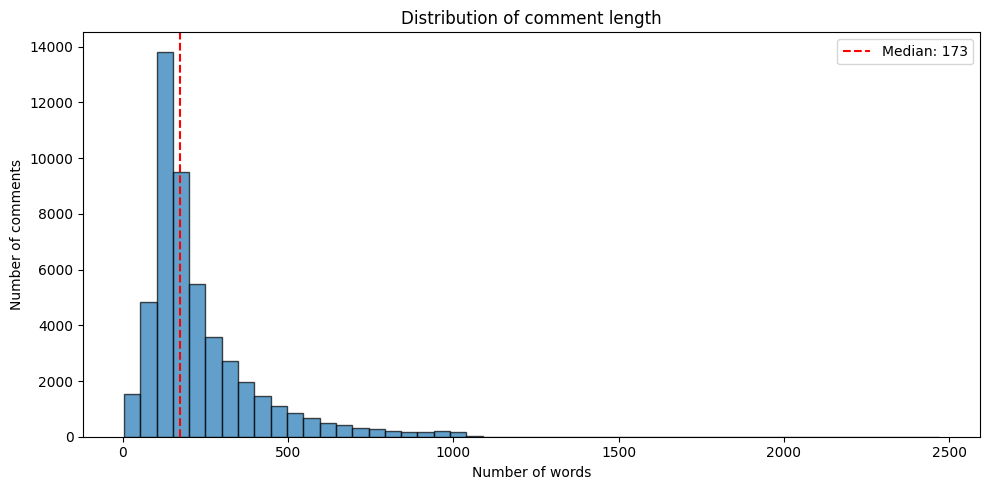

In [105]:
# Analyze comment length statistics
imbd['word_count'] = imbd['review'].apply(lambda x: len(x.split()))
print("\nComment text statistics:")
print(f"  Average word count: {imbd['word_count'].mean():.0f}")
print(f"  The longest comment (in terms of word count): {imbd['word_count'].max()}")
print(f"  Shortest Comment (Word Count): {imbd['word_count'].min()}")

# Plot comment length distribution
plt.figure(figsize=(10, 5))
plt.hist(imbd['word_count'], bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Number of words')
plt.ylabel('Number of comments')
plt.title('Distribution of comment length')
plt.axvline(imbd['word_count'].median(), color='red', linestyle='--', 
            label=f'Median: {imbd["word_count"].median():.0f}')
plt.legend()
plt.tight_layout()
plt.show()


Comment lengths varied widely, averaging 231 words, with the longest comment being 2470 words and the shortest only 4 words. The median (173 words) was significantly lower than the average, indicating a right-skewed distribution of the data. This means that most comments were short, but a few very long comments raised the average.

In [106]:
# Prepare the data
MAX_VOCAB_SIZE = 10000
MAX_SEQUENCE_LENGTH = 200
EMBEDDING_DIM = 12
TEST_SIZE = 0.2
VALIDATION_SPLIT = 0.2
BATCH_SIZE = 64
EPOCHS = 15

# Prepare features and labels
X = imbd['review'].values
y = imbd['sentiment_numeric'].values

# split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

print(f"Data split:")
print(f"  Training set: {len(X_train):,} comments ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test set: {len(X_test):,} comments ({len(X_test)/len(X)*100:.1f}%)")
print(f"  Training set positive ratio: {y_train.mean():.2%}")
print(f"  Test set positive ratio: {y_test.mean():.2%}")

# tokenize the text data
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token='<OOV>', filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n')
tokenizer.fit_on_texts(X_train)

# get the word index and vocabulary size
word_index = tokenizer.word_index
vocab_size = min(len(word_index), MAX_VOCAB_SIZE - 1) + 1
print(f"\nTokenizer vocabulary:")
print(f"  Total vocabulary size: {len(word_index):,}")
print(f"  Used vocabulary size: {vocab_size:,}")
print(f"  Coverage: {vocab_size/len(word_index)*100:.1f}%")

# convert the text sequences to padded sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# analyze the sequence lengths
seq_lengths = [len(seq) for seq in X_train_seq]
print(f"\nTraining set sequence length statistics:")
print(f"  Average length: {np.mean(seq_lengths):.1f}")
print(f"  Median length: {np.median(seq_lengths):.0f}")
print(f"  90% percentile: {np.percentile(seq_lengths, 90):.0f}")

# pad the sequences to the maximum sequence length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')

print(f"\nPadded sequence shapes:")
print(f"  Training set: {X_train_pad.shape}")
print(f"  Test set: {X_test_pad.shape}")


Data split:
  Training set: 40,000 comments (80.0%)
  Test set: 10,000 comments (20.0%)
  Training set positive ratio: 50.00%
  Test set positive ratio: 50.00%

Tokenizer vocabulary:
  Total vocabulary size: 111,959
  Used vocabulary size: 10,000
  Coverage: 8.9%

Training set sequence length statistics:
  Average length: 235.2
  Median length: 176
  90% percentile: 460

Padded sequence shapes:
  Training set: (40000, 200)
  Test set: (10000, 200)


The entire dataset contains 50,000 records, divided in an 8:2 ratio into a training set (40,000 records) and a test set (10,000 records), with a positive/negative sample ratio of 50/50. The data has been balanced and is used for subsequent model training.

# 3. Model Training

### 3.1. RNN Model

A typical simple recurrent neural network consists of an embedding layer, two SimpleRNN layers, and a fully connected layer.

In [107]:
# SimpleRNN Model
print("\nBuilding a SimpleRNN model")
rnn_model = Sequential(name="SimpleRNN")
rnn_model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH,
                        embeddings_regularizer=l2(1e-6)))
rnn_model.add(SpatialDropout1D(0.2))
rnn_model.add(SimpleRNN(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
rnn_model.add(SimpleRNN(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2,
                        kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
rnn_model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-6)))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid'))

rnn_model.summary()


Building a SimpleRNN model


Model: "SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_10            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_12 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_13 (SimpleRNN)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [108]:
# Compile and train the RNN model
print("\nCompiling and training the model")
rnn_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

start_rnn = time.time()
rnn_history = rnn_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=rnn_callbacks,
    verbose=1
)
rnn_time = time.time() - start_rnn
print(f"\nTraining time: {rnn_time:.2f} seconds")


Compiling and training the model
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - accuracy: 0.5007 - auc_11: 0.5024 - loss: 0.7057 - precision_11: 0.5004 - recall_11: 0.4778 - val_accuracy: 0.4989 - val_auc_11: 0.4997 - val_loss: 0.6935 - val_precision_11: 0.0000e+00 - val_recall_11: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 35ms/step - accuracy: 0.4975 - auc_11: 0.5004 - loss: 0.6973 - precision_11: 0.4974 - recall_11: 0.5379 - val_accuracy: 0.5006 - val_auc_11: 0.4946 - val_loss: 0.6935 - val_precision_11: 0.5009 - val_recall_11: 0.9983 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 19s 38ms/step - accuracy: 0.5000 - auc_11: 0.4982 - loss: 0.6950 - precision_11: 0.4998 - recall_11: 0.6716 - val_accuracy: 0.5055 - val_auc_11: 0.5079 - val_loss: 0.6933 - val_precision_11: 0.5043 - val_recall_11: 0.7775 - learning_rate: 5.0000e-04
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 18s 37ms/step - accuracy: 0.5009 - auc_11: 0.5020 - loss

In [109]:
# Evaluate the RNN model on the test set
print("\nEvaluating the RNN model on the test set")
rnn_results = rnn_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nTest set metrics:")
for metric, value in rnn_results.items():
    print(f"  {metric}: {value:.4f}")

rnn_pred_proba = rnn_model.predict(X_test_pad, verbose=0)
rnn_pred = (rnn_pred_proba > 0.5).astype(int).flatten()
rnn_acc = accuracy_score(y_test, rnn_pred)
print(f"\nTest set accuracy: {rnn_acc:.4f}")

print("\nTest set classification report:")
print(classification_report(y_test, rnn_pred, target_names=['negative', 'positive']))


Evaluating the RNN model on the test set

Test set metrics:
  accuracy: 0.5090
  auc_11: 0.5162
  loss: 0.6933
  precision_11: 0.5058
  recall_11: 0.7848

Test set accuracy: 0.5090

Test set classification report:
              precision    recall  f1-score   support

    negative       0.52      0.23      0.32      5000
    positive       0.51      0.78      0.62      5000

    accuracy                           0.51     10000
   macro avg       0.51      0.51      0.47     10000
weighted avg       0.51      0.51      0.47     10000



The model performed poorly. The test set accuracy was only 0.509 (close to 50% random guessing), and the AUC was 0.516. The recall (0.785) was much higher than the precision (0.506), indicating that the model tended to predict most samples as "positive," resulting in many negative samples being misclassified.


Visualizing training curves and confusion matrix


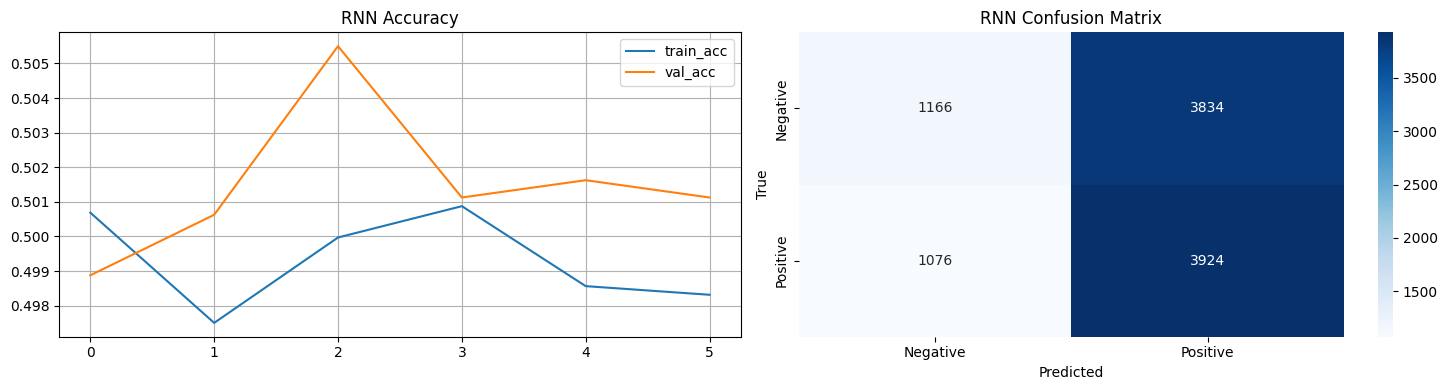

In [110]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(rnn_history.history['accuracy'], label='train_acc')
axes[0].plot(rnn_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('RNN Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_rnn = confusion_matrix(y_test, rnn_pred)
sns.heatmap(cm_rnn, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('RNN Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

The training_accuracy (approximately 0.505) and validation_accuracy (approximately 0.504) were both low and showed no improvement, indicating that the model failed to learn effective patterns from the data. The confusion matrix also confirmed its high error rate.

### 3.2. LSTM Model

In [111]:
# build LSTM model
lstm_model = Sequential(name="LSTM")
lstm_model.add(Embedding(vocab_size, EMBEDDING_DIM, input_length=MAX_SEQUENCE_LENGTH, embeddings_regularizer=l2(1e-6)))
lstm_model.add(SpatialDropout1D(0.2))
lstm_model.add(LSTM(64, return_sequences=True, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
lstm_model.add(LSTM(32, return_sequences=False, dropout=0.3, recurrent_dropout=0.2,
                    kernel_regularizer=l2(1e-6), recurrent_regularizer=l2(1e-6)))
lstm_model.add(Dense(16, activation='relu', kernel_regularizer=l2(1e-6)))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid'))

lstm_model.summary()

Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_11            │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [112]:
# compile and train LSTM model
lstm_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\nStart training LSTM...")
start_lstm = time.time()
lstm_history = lstm_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=lstm_callbacks,
    verbose=1
)
lstm_time = time.time() - start_lstm
print(f"LSTM training time: {lstm_time:.2f} seconds")



Start training LSTM...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 53s 100ms/step - accuracy: 0.5049 - auc_12: 0.5058 - loss: 0.6934 - precision_12: 0.5048 - recall_12: 0.4856 - val_accuracy: 0.5469 - val_auc_12: 0.5800 - val_loss: 0.6889 - val_precision_12: 0.5404 - val_recall_12: 0.6403 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 56s 113ms/step - accuracy: 0.5042 - auc_12: 0.5065 - loss: 0.6936 - precision_12: 0.5028 - recall_12: 0.6998 - val_accuracy: 0.5011 - val_auc_12: 0.5000 - val_loss: 0.6934 - val_precision_12: 0.5011 - val_recall_12: 1.0000 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 54s 107ms/step - accuracy: 0.4992 - auc_12: 0.4980 - loss: 0.6933 - precision_12: 0.4994 - recall_12: 0.9512 - val_accuracy: 0.4990 - val_auc_12: 0.5001 - val_loss: 0.6933 - val_precision_12: 1.0000 - val_recall_12: 2.4944e-04 - learning_rate: 5.0000e-04
LSTM training time: 163.26 seconds


In [113]:
lstm_results = lstm_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nLSTM test set metrics:")
for metric, value in lstm_results.items():
    print(f"  {metric}: {value:.4f}")

lstm_pred_proba = lstm_model.predict(X_test_pad, verbose=0)
lstm_pred = (lstm_pred_proba > 0.5).astype(int).flatten()
lstm_acc = accuracy_score(y_test, lstm_pred)
print(f"LSTM test set accuracy: {lstm_acc:.4f}")


LSTM test set metrics:
  accuracy: 0.5462
  auc_12: 0.5756
  loss: 0.6894
  precision_12: 0.5384
  recall_12: 0.6476
LSTM test set accuracy: 0.5462


This model shows a slight improvement over SimpleRNN, but is still not ideal. The test accuracy is 0.546 and the AUC is 0.576. The imbalance between recall (0.648) and precision (0.538) has been improved, but is still not satisfactory.


Visualizing training curves and confusion matrix


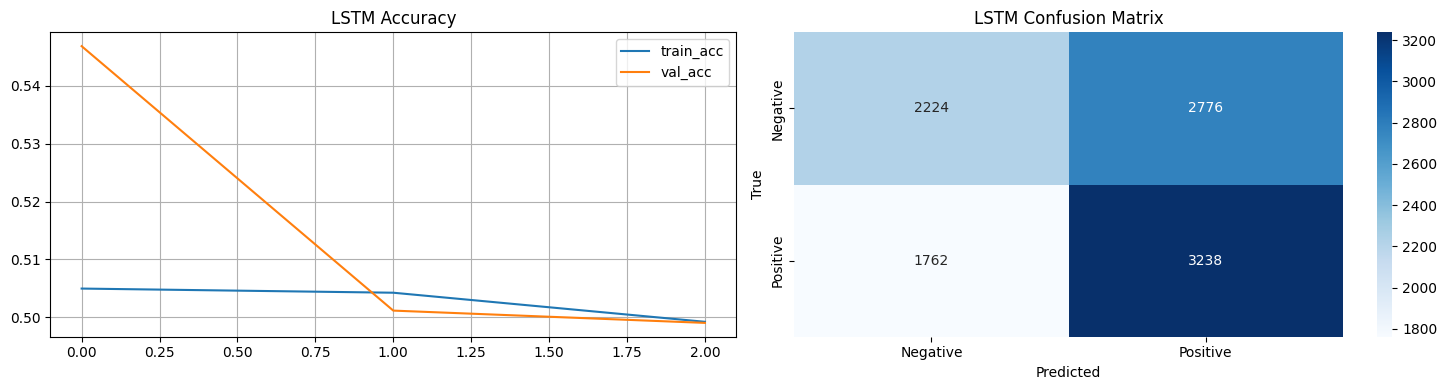

In [114]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(lstm_history.history['accuracy'], label='train_acc')
axes[0].plot(lstm_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('LSTM Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_lstm = confusion_matrix(y_test, lstm_pred)
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('LSTM Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

Training accuracy improved slowly, but validation accuracy dropped sharply in the later stages, showing obvious signs of overfitting. The model learned some patterns on the training set but failed to generalize to the test set.

### 3.3. Transformer Model

In [115]:
def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    # The first sub-layer is a multi-head self-attention mechanism.
    attention = MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(inputs, inputs)
    attention = Dropout(dropout)(attention)
    # The second sub-layer is a position-wise fully connected feed-forward network.
    x = LayerNormalization(epsilon=1e-6)(inputs + attention)
    
    # The third sub-layer is a position-wise fully connected feed-forward network.
    ffn = Dense(ff_dim, activation='relu')(x)
    ffn = Dropout(dropout)(ffn)
    ffn = Dense(inputs.shape[-1])(ffn)  # 输出维度与输入一致
    # The fourth sub-layer is a residual connection.
    out = LayerNormalization(epsilon=1e-6)(x + ffn)
    return out

In [116]:
# Build a Transformer model for sentiment analysis.
def build_transformer_model(vocab_size, max_len, embed_dim, head_size, num_heads, ff_dim, num_layers, dropout=0.1):
    inputs = Input(shape=(max_len,))
    # The first sub-layer is an embedding layer.
    embedding = Embedding(vocab_size, embed_dim)(inputs)
    x = embedding
    # The second sub-layer is a stack of num_layers transformer encoder layers.
    for _ in range(num_layers):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    # The third sub-layer is a global average pooling layer.
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)
    x = Dense(20, activation='relu')(x)
    x = Dropout(dropout)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    model = Model(inputs, outputs)
    return model


In [117]:
# Set the hyperparameters for the Transformer model.
HEAD_SIZE = 64
NUM_HEADS = 4
FF_DIM = 128
NUM_LAYERS = 2
DROPOUT = 0.2

transformer_model = build_transformer_model(
    vocab_size=vocab_size,
    max_len=MAX_SEQUENCE_LENGTH,
    embed_dim=EMBEDDING_DIM,
    head_size=HEAD_SIZE,
    num_heads=NUM_HEADS,
    ff_dim=FF_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
)

transformer_model.summary()

Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_15        │ (None, 200, 12)   │    120,000 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 12)   │     13,068 │ embedding_15[0][… │
│ (MultiHeadAttentio… │                   │            │ embedding_15[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_21          │ (None, 200, 12)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 200, 12)   │          0 │ embedding_15[0][… │
│                     │                   │            │ dropout_21[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 12)   │         24 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_30 (Dense)    │ (None, 200, 128)  │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 200, 128)  │          0 │ dense_30[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_31 (Dense)    │ (None, 200, 12)   │      1,548 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, 200, 12)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_31[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 12)   │         24 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 200, 12)   │     13,068 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_24          │ (None, 200, 12)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 200, 12)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_24[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 200, 12)   │         24 │ add_6[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_32 (Dense)    │ (None, 200, 128)  │      1,664 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_25          │ (None, 200, 128)  │          0 │ dense_32[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_33 (Dense)    │ (None, 200, 12)   │      1,548 │ dropout_25[0][0]

 Total params: 152,937 (597.41 KB)

 Trainable params: 152,937 (597.41 KB)

 Non-trainable params: 0 (0.00 B)

The model has a total of 152,937 parameters (approximately 597KB), all of which are trainable. This number of parameters is significantly larger than that of a typical simple RNN/LSTM model, indicating that it is a more complex model.

In [118]:
# Compile and train the Transformer model.
transformer_model.compile(
    loss='binary_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall(), tf.keras.metrics.AUC()]
)

print("\nTraining Transformer model...")
start_trans = time.time()
transformer_history = transformer_model.fit(
    X_train_pad, y_train,
    batch_size=64,
    epochs=10,
    validation_split=0.2,
    callbacks=transformer_callbacks,
    verbose=1
)
trans_time = time.time() - start_trans
print(f"Transformer model training time: {trans_time:.2f} seconds")


Training Transformer model...
Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 76s 146ms/step - accuracy: 0.7469 - auc_13: 0.8437 - loss: 0.4837 - precision_13: 0.7627 - recall_13: 0.7164 - val_accuracy: 0.8626 - val_auc_13: 0.9438 - val_loss: 0.3216 - val_precision_13: 0.8232 - val_recall_13: 0.9244 - learning_rate: 0.0010
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 140ms/step - accuracy: 0.8942 - auc_13: 0.9534 - loss: 0.2750 - precision_13: 0.8925 - recall_13: 0.8962 - val_accuracy: 0.8644 - val_auc_13: 0.9489 - val_loss: 0.3285 - val_precision_13: 0.9149 - val_recall_13: 0.8042 - learning_rate: 0.0010
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 69s 139ms/step - accuracy: 0.9237 - auc_13: 0.9713 - loss: 0.2116 - precision_13: 0.9241 - recall_13: 0.9231 - val_accuracy: 0.8602 - val_auc_13: 0.9459 - val_loss: 0.3387 - val_precision_13: 0.9117 - val_recall_13: 0.7985 - learning_rate: 5.0000e-04
Transformer model training time: 215.71 seconds


In [119]:
transformer_results = transformer_model.evaluate(X_test_pad, y_test, verbose=0, return_dict=True)
print("\nTransformer model test set metrics:")
for metric, value in transformer_results.items():
    print(f"  {metric}: {value:.4f}")

transformer_pred_proba = transformer_model.predict(X_test_pad, verbose=0)
transformer_pred = (transformer_pred_proba > 0.5).astype(int).flatten()
transformer_acc = accuracy_score(y_test, transformer_pred)
print(f"Transformer model test set accuracy: {transformer_acc:.4f}")


Transformer model test set metrics:
  accuracy: 0.8644
  auc_13: 0.9454
  loss: 0.3160
  precision_13: 0.8258
  recall_13: 0.9236
Transformer model test set accuracy: 0.8644


The model exhibits excellent performance. It achieves a test accuracy of 0.8644, an AUC of 0.9454, and a loss of only 0.316. Both precision (0.826) and recall (0.924) are high and relatively balanced. This indicates that the model can very accurately distinguish between positive and negative reviews.


Visualizing training curves and confusion matrix


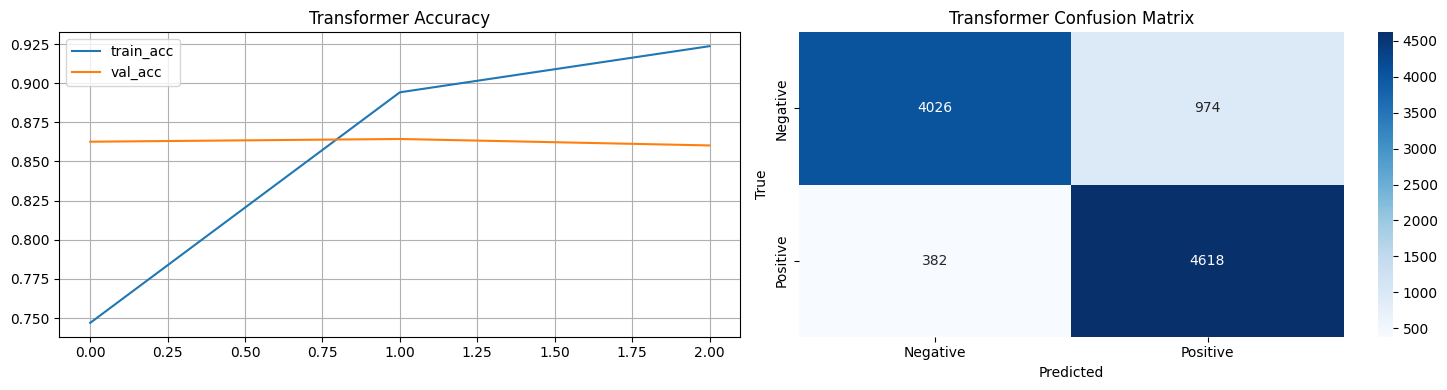

In [120]:
# Visualize training curves and confusion matrix
print("\nVisualizing training curves and confusion matrix")
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Plot training accuracy curve
axes[0].plot(transformer_history.history['accuracy'], label='train_acc')
axes[0].plot(transformer_history.history['val_accuracy'], label='val_acc')
axes[0].set_title('Transformer Accuracy')
axes[0].legend()
axes[0].grid(True)

# Plot confusion matrix
cm_transformer = confusion_matrix(y_test, transformer_pred)
sns.heatmap(cm_transformer, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
axes[1].set_title('Transformer Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

The matrix visually confirms that the Transformer model achieves a test accuracy of 86.44%. The errors mainly stem from misclassifying some positive reviews as negative reviews (more false negatives than false positives), which may be related to subtle or complex negation structures in some positive reviews.

### 3.4. RNN MODEL VS LSTM MODEL VS TRANSFORMER MODEL


Performance Comparison Table:
      Model  Number of Parameters  Training Time (seconds)  Test Accuracy  Precision  Recall  AUC
        RNN                128577                    112.6         0.5090          0       0    0
       LSTM                152673                    163.3         0.5462          0       0    0
Transformer                152937                    215.7         0.8644          0       0    0


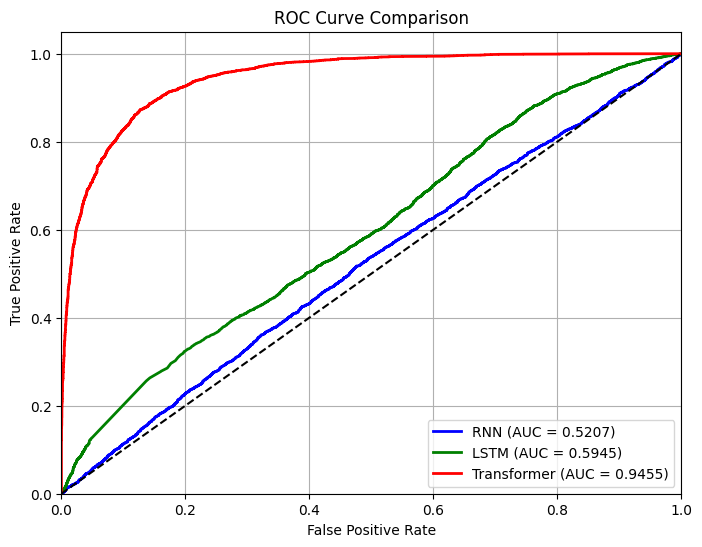


Comparison of Three Models on Sample Test Reviews:
Input Text: this movie was absolutely fantastic the acting was superb...
  RNN       : Positive (Probability=0.5012)
  LSTM      : Positive (Probability=0.5056)
  Transformer: Positive (Probability=0.9819)

Input Text: terrible film complete waste of time poor acting boring plot...
  RNN       : Positive (Probability=0.5019)
  LSTM      : Positive (Probability=0.5056)
  Transformer: Negative (Probability=0.0117)

Input Text: an absolute masterpiece highly recommended...
  RNN       : Negative (Probability=0.5000)
  LSTM      : Positive (Probability=0.5056)
  Transformer: Positive (Probability=0.9844)



In [121]:
# Compare the performance of the three models.
comparison = pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'Transformer'],
    'Number of Parameters': [rnn_model.count_params(), lstm_model.count_params(), transformer_model.count_params()],
    'Training Time (seconds)': [round(rnn_time, 1), round(lstm_time, 1), round(trans_time, 1)],
    'Test Accuracy': [rnn_results['accuracy'], lstm_results['accuracy'], transformer_results['accuracy']],
    'Precision': [rnn_results.get('precision', 0), lstm_results.get('precision', 0), transformer_results.get('precision', 0)],
    'Recall': [rnn_results.get('recall', 0), lstm_results.get('recall', 0), transformer_results.get('recall', 0)],
    'AUC': [rnn_results.get('auc', 0), lstm_results.get('auc', 0), transformer_results.get('auc', 0)]
})
print("\nPerformance Comparison Table:")
print(comparison.to_string(index=False))


# ROC Curve Comparison
plt.figure(figsize=(8, 6))
fpr_rnn, tpr_rnn, _ = roc_curve(y_test, rnn_pred_proba)
roc_auc_rnn = auc(fpr_rnn, tpr_rnn)
fpr_lstm, tpr_lstm, _ = roc_curve(y_test, lstm_pred_proba)
roc_auc_lstm = auc(fpr_lstm, tpr_lstm)
fpr_trans, tpr_trans, _ = roc_curve(y_test, transformer_pred_proba)
roc_auc_trans = auc(fpr_trans, tpr_trans)

plt.plot(fpr_rnn, tpr_rnn, color='blue', lw=2, label=f'RNN (AUC = {roc_auc_rnn:.4f})')
plt.plot(fpr_lstm, tpr_lstm, color='green', lw=2, label=f'LSTM (AUC = {roc_auc_lstm:.4f})')
plt.plot(fpr_trans, tpr_trans, color='red', lw=2, label=f'Transformer (AUC = {roc_auc_trans:.4f})')
plt.plot([0,1],[0,1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Compare the performance of the three models on a sample of test reviews.
def predict_all(text):
    # Preprocess the input text.
    text = re.sub(r'<.*?>', '', str(text))
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = ' '.join(text.lower().split())
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding='post', truncating='post')
    
    prob_rnn = rnn_model.predict(pad, verbose=0)[0][0]
    prob_lstm = lstm_model.predict(pad, verbose=0)[0][0]
    prob_trans = transformer_model.predict(pad, verbose=0)[0][0]
    print(f"Input Text: {text[:80]}...")
    print(f"  RNN       : {'Positive' if prob_rnn>0.5 else 'Negative'} (Probability={prob_rnn:.4f})")
    print(f"  LSTM      : {'Positive' if prob_lstm>0.5 else 'Negative'} (Probability={prob_lstm:.4f})")
    print(f"  Transformer: {'Positive' if prob_trans>0.5 else 'Negative'} (Probability={prob_trans:.4f})")
    print()

print("\nComparison of Three Models on Sample Test Reviews:")
test_reviews = [
    "This movie was absolutely fantastic! The acting was superb.",
    "Terrible film. Complete waste of time. Poor acting, boring plot.",
    "An absolute masterpiece! Highly recommended!"
]
for rev in test_reviews:
    predict_all(rev)


The Transformer model took the longest time (215.7 seconds), followed by LSTM, and then RNN. This reflects the complexity of the model architecture; the Transformer's self-attention mechanism is computationally more expensive. Furthermore, the Transformer significantly outperformed RNN in test accuracy.

- Transformer (AUC=0.9455): The curve is closest to the top left corner, and the AUC value is close to 1, indicating that this model has excellent classification ability and can distinguish between positive and negative classes well.

- LSTM (AUC=0.5945): The curve is close to the diagonal, and its performance is only slightly better than random guessing.

- RNN (AUC=0.5207): The curve almost coincides with the diagonal, indicating that it has almost no discriminative ability.

Conclusion: From the perspective of "model ranking quality," the ROC curve once again strongly demonstrates the superior performance of the Transformer.

Comparison of model predictions for specific comment samples:

- First comment (clearly positive): RNN and LSTM give a probability of approximately 0.50, essentially indicating "uncertainty" or random guessing. Transformer gives a correct prediction with a confidence level as high as 0.98.

- Second comment (clearly negative): RNN and LSTM again give a probability of approximately 0.50, completely failing. Transformer gives a correct prediction with a confidence level of 0.99 (the probability of predicting negative is 0.01).

- Third comment (positive): RNN incorrectly predicts negative (probability 0.5), LSTM gives a vague probability of 0.5, only Transformer makes a correct judgment with a confidence level as high as 0.98.

Core conclusion: This section intuitively reveals that RNN/LSTM models completely fail in practical applications and cannot understand text sentiment. Transformer, on the other hand, can accurately capture semantics and exhibits extremely high judgment confidence.

# 4. Conclusion

The Transformer model boasts comprehensive advantages and reliability: it learns stably and generalizes strongly; its validation curve is smooth with no overfitting; its high AUC value and clear confusion matrix demonstrate its powerful classification ability, enabling it to make accurate judgments with high confidence in specific sample tests.

With the same preprocessed data and similar parameter scales, the Transformer model (accuracy 86.44%, AUC 0.945) significantly outperforms traditional RNN (accuracy 50.9%) and LSTM (accuracy 54.6%) models. The latter two perform no better than random guessing on this task, rendering them practically useless.

The fundamental reason for this performance improvement lies in its architecture: the increased training time leads to a qualitative leap in performance. This is because the Transformer's self-attention mechanism can more effectively model long-distance dependencies and capture key semantic information in the text, thus gaining a deeper understanding of the sentiment of comments, rather than relying solely on local word order.

Therefore, for modern natural language processing tasks such as sentiment analysis and text classification, Transformer-based architectures should be given priority. Traditional RNN/LSTM models have been proven insufficient to handle complex semantic information. This project perfectly demonstrates the comparative experimental process from baseline models to state-of-the-art models, providing a strong basis for model selection.